In [2]:
import cv2
import numpy as np 
print("Successfully imported")

Successfully imported


In [3]:
import zipfile
import os
import matplotlib.pyplot as plt

In [6]:
with zipfile.ZipFile("DeepGlobe_Road.zip",'r') as zip_ref:
    zip_ref.extractall("DeepGlobe_Dataset")

In [7]:
print(os.listdir("DeepGlobe_Dataset"))

['class_dict.csv', 'metadata.csv', 'test', 'train', 'valid']


In [8]:
print(os.listdir("DeepGlobe_Dataset/train"))

['100034_mask.png', '100034_sat.jpg', '100081_mask.png', '100081_sat.jpg', '100129_mask.png', '100129_sat.jpg', '100703_mask.png', '100703_sat.jpg', '100712_mask.png', '100712_sat.jpg', '100773_mask.png', '100773_sat.jpg', '100841_mask.png', '100841_sat.jpg', '100867_mask.png', '100867_sat.jpg', '100892_mask.png', '100892_sat.jpg', '101225_mask.png', '101225_sat.jpg', '101296_mask.png', '101296_sat.jpg', '101395_mask.png', '101395_sat.jpg', '102408_mask.png', '102408_sat.jpg', '10246_mask.png', '10246_sat.jpg', '10255_mask.png', '10255_sat.jpg', '102699_mask.png', '102699_sat.jpg', '102925_mask.png', '102925_sat.jpg', '102945_mask.png', '102945_sat.jpg', '103056_mask.png', '103056_sat.jpg', '103201_mask.png', '103201_sat.jpg', '103341_mask.png', '103341_sat.jpg', '103447_mask.png', '103447_sat.jpg', '103627_mask.png', '103627_sat.jpg', '103722_mask.png', '103722_sat.jpg', '104350_mask.png', '104350_sat.jpg', '104607_mask.png', '104607_sat.jpg', '10466_mask.png', '10466_sat.jpg', '10468

Total images: 6226


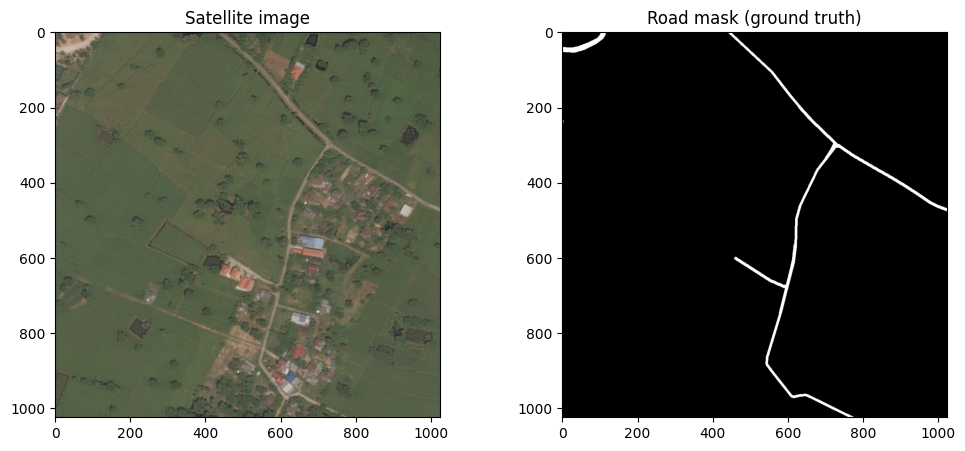

In [26]:
import matplotlib.pyplot as plt
data_dir = "DeepGlobe_Dataset/train"
samples = [f.replace("_sat.jpg", "") for f in os.listdir(data_dir) if f.endswith("_sat.jpg")]
print(f"Total images: {len(samples)}")
# Visualize one sample
idx = samples[3]
sat = cv2.imread(f"{data_dir}/{idx}_sat.jpg")
mask = cv2.imread(f"{data_dir}/{idx}_mask.png", cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(sat, cv2.COLOR_BGR2RGB))
axes[0].set_title("Satellite image")
axes[1].imshow(mask, cmap='gray')
axes[1].set_title("Road mask (ground truth)")
plt.show()


In [11]:
def fragment_image(img_id, img, overlap=0.35, rows=3, cols=3):
    if img is None :
        raise ValueError("Image not loaded")
    h, w = img.shape[:2]
    frag_h = int(h / (1 + (rows - 1) * (1 - overlap)))
    frag_w = int(w / (1 + (cols - 1) * (1 - overlap)))
    fragments = []
    for i in range(rows):
        for j in range(cols):
            y1 = int(i * frag_h * (1 - overlap))
            x1 = int(j * frag_w * (1 - overlap))
            y2 = min(y1 + frag_h, h)
            x2 = min(x1 + frag_w, w)
            frag = img[y1:y2, x1:x2]
            fragments.append({
                "img_id": img_id,       # which map this came from
                "grid_pos": (i, j),     # ground truth position
                "x1": x1, "y1": y1,
                "x2": x2, "y2": y2,
                "image": frag
            })
    return fragments

In [13]:
import json
import random

def create_dataset(data_dir, out_dir, num_maps=5, overlap=0.35):
    os.makedirs(out_dir, exist_ok=True)
    samples = [f.replace("_sat.jpg","") for f in os.listdir(data_dir) if f.endswith("_sat.jpg")]
    selected = random.sample(samples, min(num_maps, len(samples)))

    all_fragments = []
    metadata = []

    for img_id in selected:
        img = cv2.imread(f"{data_dir}/{img_id}_sat.jpg")
        frags = fragment_image(img_id, img, overlap=overlap)
        all_fragments.extend(frags)

    #shuffle 
    random.shuffle(all_fragments)

    for idx, frag in enumerate(all_fragments):
        fname = f"frag_{idx:04d}.jpg"
        cv2.imwrite(f"{out_dir}/{fname}", frag["image"])
        metadata.append({
            "file": fname,
            "img_id": frag["img_id"],
            "grid_pos": list(frag["grid_pos"]),
            "x1": frag["x1"], "y1": frag["y1"],
            "x2": frag["x2"], "y2": frag["y2"]
        })

    with open(f"{out_dir}/metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"Created {len(all_fragments)} fragments from {len(selected)} maps")
    return metadata


In [18]:
out_dir = "DeepGlobe_Dataset/fragments"
metadata = create_dataset(data_dir, out_dir)

Created 45 fragments from 5 maps


In [17]:
def show_fragments(out_dir, num=6):
    files = [f for f in os.listdir(out_dir) if f.endswith(".jpg")]

    plt.figure(figsize=(10, 6))

    for i in range(min(num, len(files))):
        img_path = os.path.join(out_dir, files[i])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(files[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

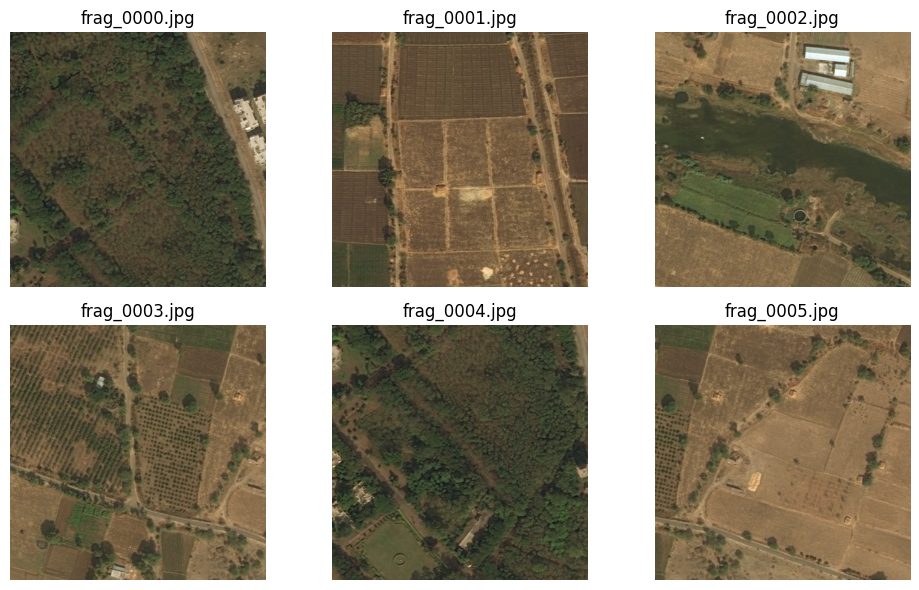

In [31]:
show_fragments(out_dir)

In [ ]:
samples_1 = [f.replace("_sat.jpg","") for f in os.listdir(data_dir) if f.endswith("_sat.jpg")]
print(len(samples_1))

6226


In [25]:
samples_2 = [f for f in os.listdir(out_dir) if f.endswith(".jpg")]
print(len(samples_2))

45


#why ids it bgr in cv ?
#what is hsv
#diff btww bgr and hsv

# visualizing different groups

In [40]:

components = list(nx.connected_components(G))
print(f"Total groups : {len(components)}")

Total groups : 5


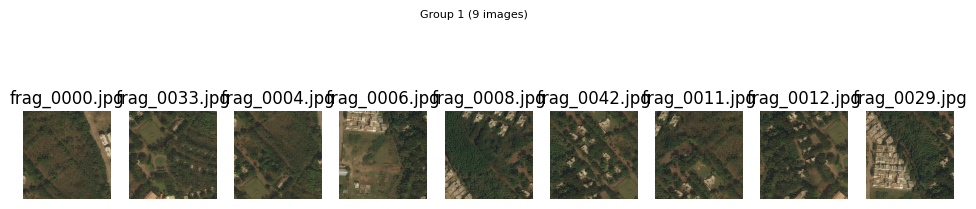

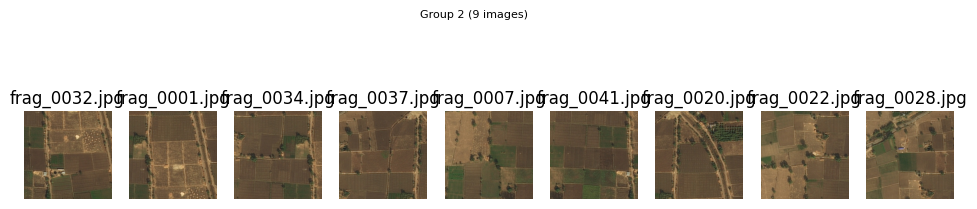

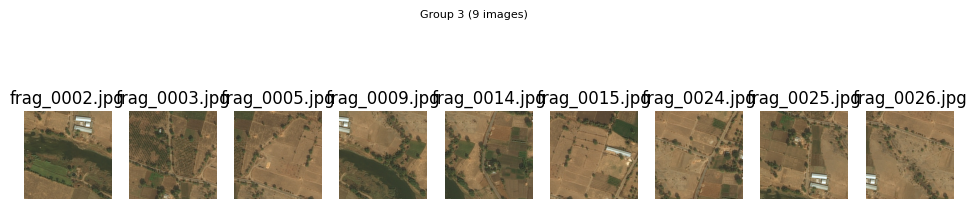

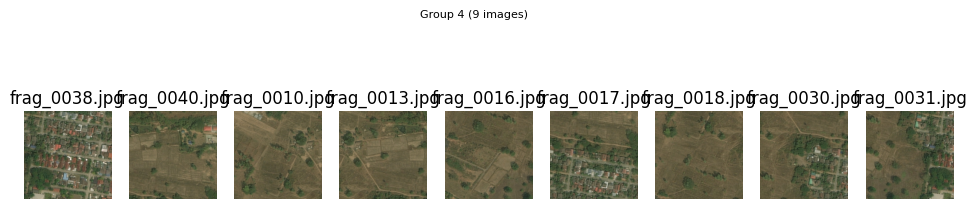

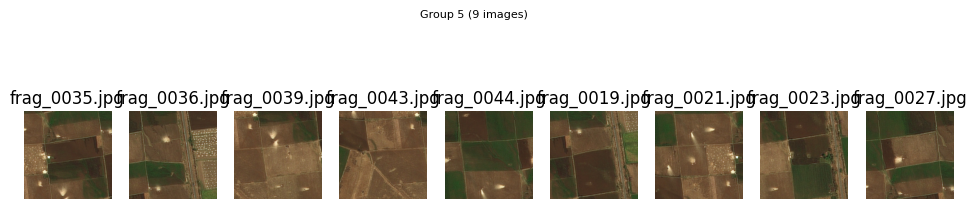

In [41]:
import matplotlib.pyplot as plt

for idx, comp in enumerate(components):
    comp = list(comp)
    n = len(comp)

    plt.figure(figsize=(12, 3))

    for i, node in enumerate(comp):
        plt.subplot(1, n, i+1)
        img = fragments[node]["img"]
        
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"{frag_files[node]}")
        plt.axis("off")

    plt.suptitle(f"Group {idx+1} ({n} images)", fontsize=8)
    plt.show()